In [42]:
import os
import cv2
from time import time
import numpy as np
from sklearn.utils import shuffle


from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 6]

In [43]:
folder = '../../computer_vision/lesson_12/data/subset_homework'

def printClass(folder, classpath):
    
    fnames = os.listdir(os.path.join(folder, classpath))
    images = [cv2.imread(os.path.join(folder, classpath, f), cv2.IMREAD_UNCHANGED) for f in fnames]    
    print(f"size of {classpath} :", np.array(images).shape)
    return images

images0 = printClass(folder, 'class_id_0')
labels0 = [0] * len(images0)

images1 = printClass(folder, 'class_id_1')
labels1 = [1] * len(images1)



size of class_id_0 : (2220, 28, 28)
size of class_id_1 : (2250, 28, 28)


In [44]:
# Put together and shuffle the data
images = images0 + images1
labels = labels0 + labels1
images, labels = shuffle(images, labels)

images = np.array(images)
labels = np.array(labels)

print('Images', images.shape)
print('Labels', labels.shape)

Images (4470, 28, 28)
Labels (4470,)


In [ ]:
import tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras.layers import Dense, Input
print(tf.__version__)

pixels = np.array([image.flatten() for image in images]) / 255.0

inputs = Input(shape=(pixels0.shape[1],))
outputs = Dense(1, activation="linear")(inputs)
outputs = Dense(1, activation="linear")(outputs)
model = Model(inputs, outputs)

model.summary()

model.compile(optimizer ='adam', loss = 'mean_squared_error')

history = model.fit(pixels, labels, epochs=30, batch_size=32)

2.16.2


Model: "functional_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_14 (InputLayer)     │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │           785 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 787 (3.07 KB)

 Trainable params: 787 (3.07 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.3712
Epoch 2/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.2474
Epoch 3/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1921
Epoch 4/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1586
Epoch 5/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1400
Epoch 6/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1203
Epoch 7/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1128
Epoch 8/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1047
Epoch 9/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1000
Epoch 10/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0973
Epoch 11/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0930
Epoch 12/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0992
Epoch 13/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0937
Epoch 14/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0904
Epoch 15/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - lo

In [37]:
tf.keras.utils.plot_model(model, to_file="model.png", show_shapes=True, show_layer_names=True)

You must install pydot (`pip install pydot`) for `plot_model` to work.


(Text(0.5, 0, 'epoch'), Text(0, 0.5, 'loss'))

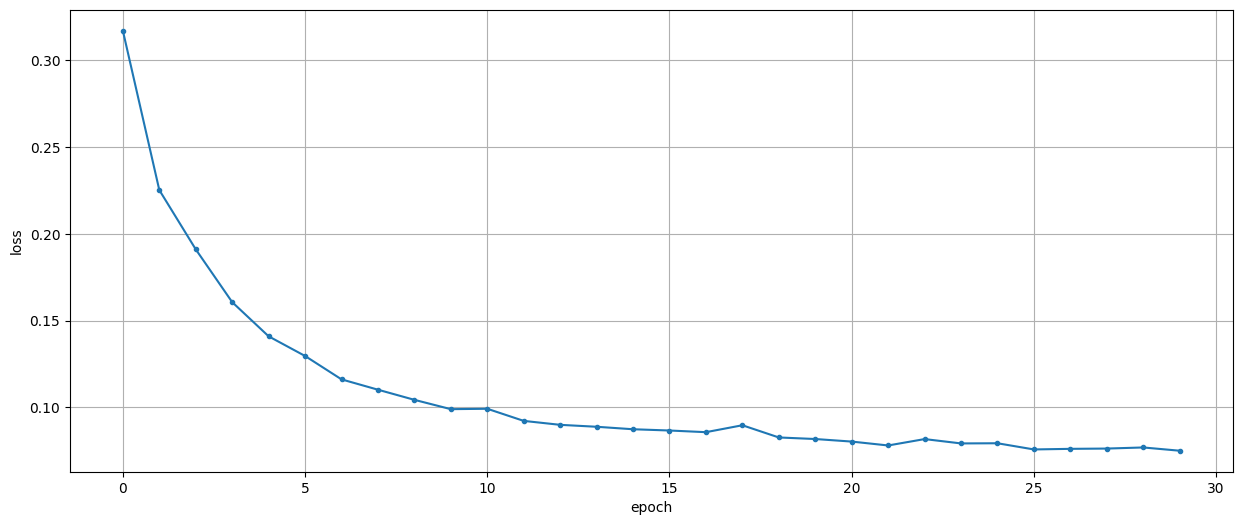

In [38]:
h = history.history
epochs = range(len(h['loss']))
plt.plot(epochs, h['loss'], '.-'), plt.grid(True)
plt.xlabel('epoch'), plt.ylabel('loss')

In [40]:
predictions = model.predict(pixels).squeeze()
predictions = predictions > 0.5
correct = 0

for prediction, label in zip(predictions, labels):
    if prediction == label:
        correct  = correct + 1

print('Accuracy = ', correct/len(labels))

140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Accuracy =  0.967337807606264
